# Titanic-Datensatz

## Laden der einzelnen Datensätze

In [112]:
import pandas as pd
import numpy as np

In [113]:
titanic_part1_df = pd.read_csv('titanic.csv')
titanic_part1_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [114]:
titanic_part2_incomplete_df = pd.read_csv('titanic_part2_incomplete.csv')
titanic_part2_incomplete_df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,951,1,"Chaudanson, Miss. Victorine",female,36.0,0,0,PC 17608,262.3750,B61,C
1,952,3,"Dika, Mr. Mirko",male,17.0,0,0,349232,7.8958,NaN,S
2,953,2,"McCrae, Mr. Arthur Gordon",male,32.0,0,0,237216,13.5000,NaN,S
3,954,3,"Bjorklund, Mr. Ernst Herbert",male,18.0,0,0,347090,7.7500,NaN,S
4,955,3,"Bradley, Miss. Bridget Delia",female,22.0,0,0,334914,7.7250,NaN,Q


In [115]:
titanic_part2_survival_df = pd.read_csv('titanic_part2_survival.csv')
titanic_part2_survival_df.head()

,PassengerId,Survived
0,951,0
1,952,0
2,953,0
3,954,0
4,955,0


## Aufbauen des Gesamt-DataFrames

* Joinen / Mergen von incomplete und survival

In [116]:
titanic_part2_df = pd.merge(titanic_part2_incomplete_df, titanic_part2_survival_df, how='inner', on='PassengerId')
titanic_part2_df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survived
0,951,1,"Chaudanson, Miss. Victorine",female,36.0,0,0,PC 17608,262.3750,B61,C,0
1,952,3,"Dika, Mr. Mirko",male,17.0,0,0,349232,7.8958,NaN,S,0
2,953,2,"McCrae, Mr. Arthur Gordon",male,32.0,0,0,237216,13.5000,NaN,S,0
3,954,3,"Bjorklund, Mr. Ernst Herbert",male,18.0,0,0,347090,7.7500,NaN,S,0
4,955,3,"Bradley, Miss. Bridget Delia",female,22.0,0,0,334914,7.7250,NaN,Q,0


* Konkatination des Datensatzes
    * unter fortlaufendem Index

In [117]:
df = pd.concat([titanic_part1_df, titanic_part2_df], ignore_index=True)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [118]:
df.shape

(1308, 12)

## Exploration

In [119]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1308 entries, 0 to 1307
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1308 non-null   int64  
 1   Survived     1308 non-null   int64  
 2   Pclass       1308 non-null   int64  
 3   Name         1308 non-null   object 
 4   Sex          1308 non-null   object 
 5   Age          1045 non-null   float64
 6   SibSp        1308 non-null   int64  
 7   Parch        1308 non-null   int64  
 8   Ticket       1308 non-null   object 
 9   Fare         1307 non-null   float64
 10  Cabin        295 non-null    object 
 11  Embarked     1306 non-null   object 
dtypes: float64(2), int64(5), object(5)
memory usage: 122.8+ KB


* Bedeutung der Spalten
    * PassengerId
    * Survived: 0=verstorben, 1=überlebt
    * PClass: 1.-4. Klasse
    * Name
    * Sex: male / female
    * Age > 0, < 125
    * SibSp = Siblings (Verwandte) / Spouse (PartnerIn)
    * Parch = Parents / Children
    * Ticket = Identifier, Zufallszahl, Reisebüro, ...
    * Fare = Preis
    * Cabin = Kabinennummer, beginnend mit einem Zeichen im Schiiffsbereich A-F und einer Nummer
    * Embarked = Zustiegspunkte, (S=Southhampton, Q = Queenstown, C = Cherbourg)

In [120]:
df.nunique()

PassengerId    1308
Survived          2
Pclass            3
Name           1306
Sex               2
Age              98
SibSp             7
Parch             8
Ticket          928
Fare            281
Cabin           186
Embarked          3
dtype: int64

In [121]:
df['Embarked'].unique()

array(['S', 'C', 'Q', nan], dtype=object)

* Identifikation von NaNs

In [122]:
df[df['Embarked'].isna()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN


* Plausibilitäten

In [123]:
f'Anzahl Alter < 0: {(df["Age"] < 0).sum()}'

'Anzahl Alter < 0: 0'

In [124]:
f'Anzahl Alter > 125: {(df["Age"] > 125).sum()}'

'Anzahl Alter > 125: 0'

* Zusammenfassung
    * Kategorien sind Survived, Sex, Embarked, Pclass
    * Ticket-Spalte ist unnötig
    * PassengerId ist auch als Index geeignet
    * Cabin hat zwei Teile: Bereich = Kategorie, Kabinennummer im Bereich
    * Nicht gesetzte Werte insbesondere im Age
        * Umgang: Löschen von Datensätzen, Drop der Spalte, Setzen mit einem vernünftigen Wert

## Cleanup

In [125]:
if 'PassengerId' in df.columns:
    df.set_index('PassengerId', inplace=True)

In [126]:
if 'Ticket' in df.columns:
    df.drop('Ticket', axis=1, inplace=True)

In [127]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1308 entries, 1 to 1309
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  1308 non-null   int64  
 1   Pclass    1308 non-null   int64  
 2   Name      1308 non-null   object 
 3   Sex       1308 non-null   object 
 4   Age       1045 non-null   float64
 5   SibSp     1308 non-null   int64  
 6   Parch     1308 non-null   int64  
 7   Fare      1307 non-null   float64
 8   Cabin     295 non-null    object 
 9   Embarked  1306 non-null   object 
dtypes: float64(2), int64(4), object(4)
memory usage: 112.4+ KB


* Einführen von Kategorien

In [128]:
category_columns = ['Sex', 'Survived', 'Pclass', 'Embarked']
for column in category_columns:
    df[column] = pd.Categorical(df[column])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1308 entries, 1 to 1309
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   Survived  1308 non-null   category
 1   Pclass    1308 non-null   category
 2   Name      1308 non-null   object  
 3   Sex       1308 non-null   category
 4   Age       1045 non-null   float64 
 5   SibSp     1308 non-null   int64   
 6   Parch     1308 non-null   int64   
 7   Fare      1307 non-null   float64 
 8   Cabin     295 non-null    object  
 9   Embarked  1306 non-null   category
dtypes: category(4), float64(2), int64(2), object(2)
memory usage: 77.1+ KB


* Umgang mit Nicht-gesetztem Alter

In [129]:
df.dropna()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C85,C
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,C123,S
7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,51.8625,E46,S
11,1,3,"Sandstrom, Miss. Marguerite Rut",female,4.0,1,1,16.7000,G6,S
12,1,1,"Bonnell, Miss. Elizabeth",female,58.0,0,0,26.5500,C103,S
...,...,...,...,...,...,...,...,...,...,...
1296,1,1,"Frauenthal, Mr. Isaac Gerald",male,43.0,1,0,27.7208,D40,C
1297,0,2,"Nourney, Mr. Alfred (Baron von Drachstedt"")""",male,20.0,0,0,13.8625,D38,C
1299,0,1,"Widener, Mr. George Dunton",male,50.0,1,1,211.5000,C80,C


In [130]:
df.dropna(axis=1)

,Survived,Pclass,Name,Sex,SibSp,Parch
PassengerId,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,1,0
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,1,0
3,1,3,"Heikkinen, Miss. Laina",female,0,0
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,1,0
5,0,3,"Allen, Mr. William Henry",male,0,0
...,...,...,...,...,...,...
1305,0,3,"Spector, Mr. Woolf",male,0,0
1306,0,1,"Oliva y Ocana, Dona. Fermina",female,0,0
1307,0,3,"Saether, Mr. Simon Sivertsen",male,0,0


* Ersetze ein Nicht-gesetztes Alter mit dem median-Wert aller Passagiere
    * Optional: Unterscheide noch das Geschlecht
        * Hinweis: Eine Und-Verknüpfung bei Pandas immer mit einem `&`, nicht `and`

In [131]:
male_median_age = df[df['Sex'] == 'male']['Age'].median()
female_median_age = df[df['Sex'] == 'female']['Age'].median()
print(f'male median age: {male_median_age}, female median age: {female_median_age}')
df.loc[df['Age'].isna() & (df['Sex'] == 'male'), 'Age'] = male_median_age
df.loc[df['Age'].isna() & (df['Sex'] == 'female'), 'Age'] = female_median_age

male median age: 28.0, female median age: 27.0


In [132]:
df['Age'].isna().sum()

np.int64(0)

In [133]:
df.tail()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,
1305,0,3,"Spector, Mr. Woolf",male,28.0,0,0,8.0500,NaN,S
1306,0,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,108.9000,C105,C
1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,7.2500,NaN,S
1308,0,3,"Ware, Mr. Frederick",male,28.0,0,0,8.0500,NaN,S
1309,1,3,"Peter, Master. Michael J",male,28.0,1,1,22.3583,NaN,C


* Cabin

In [134]:
if 'Cabin' in df.columns:
    df['ShipArea'] = df['Cabin'].astype(str).str[0]#
    df.loc[df['ShipArea'] == 'n', 'ShipArea'] = 'unknown'
    df.drop('Cabin', axis=1, inplace=True)
df.head()


,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,ShipArea
PassengerId,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,S,unknown
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,S,unknown
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,S,C
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,S,unknown


## Deskriptive Statistik

In [135]:
df.describe()

,Age,SibSp,Parch,Fare
count,1308.000000,1308.000000,1308.000000,1307.000000
mean,29.441644,0.499235,0.385321,33.315024
std,12.919102,1.041965,0.865826,51.773651
min,0.170000,0.000000,0.000000,0.000000
25%,22.000000,0.000000,0.000000,7.895800
50%,28.000000,0.000000,0.000000,14.454200
75%,35.000000,1.000000,0.000000,31.275000
max,80.000000,8.000000,9.000000,512.329200


C:\Users\raine\AppData\Local\Temp\ipykernel_2696\1993724018.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.hist(column='Age', by='Sex')


array([<Axes: title={'center': 'female'}>,
       <Axes: title={'center': 'male'}>], dtype=object)

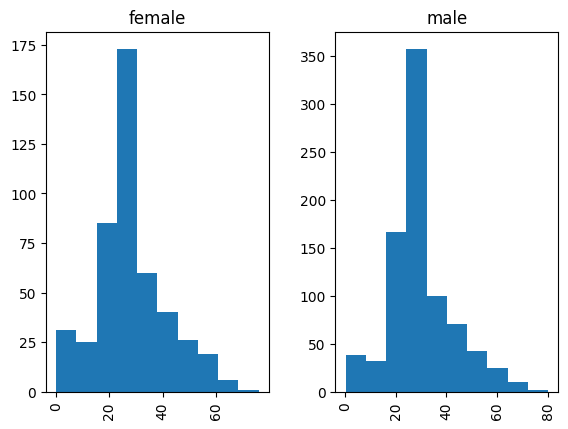

In [ ]:
df.hist(column='Age', by='Sex')

<Axes: title={'center': 'Age'}, xlabel='Sex'>

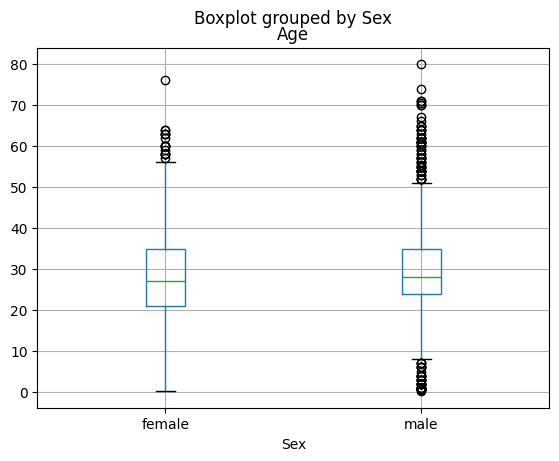

In [137]:
df.boxplot(column='Age', by='Sex')